**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="../figures/copilot.png">

# Assignment 1 Part 2: Modelling Boids as a Lagrangian System


In [107]:
# Import all the required libraries here
import torch as T
from torch import nn
from torch.utils.data import Dataset
from torch_geometric.data import Data, DataLoader as GraphDataLoader
import lightning as L
import torch.nn.functional as F
from torch_geometric.utils import to_dense_batch
import os
import pickle
from torch.utils.data import Dataset, Subset
import numpy as np 
import matplotlib.pyplot as plt


print(f"Success! Running PyTorch {T.__version__} and Lightning {L.__version__}")
cuda_available = T.cuda.is_available()
if cuda_available:
    print(f"CUDA is available! Device count: {T.cuda.device_count()}")
else:
    print("CUDA is not available.")

Success! Running PyTorch 2.14.0 and Lightning 2.6.6
CUDA is not available.


In [108]:
class BoidsDataset(Dataset):
    """Dataset for the Boids simulation data."""

    def __init__(self, path):
        self.path = path
        self.nodes = T.tensor([], dtype=T.float32)  
        self.edge_index = T.tensor([], dtype=T.long)
        self.edge_attributes = T.tensor([], dtype=T.float32) 
        self.n_simulations = 0
        self.traj_length = 0

    def load_data(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(
                f"Data file not found at {self.path}. Please check the path and try again."
            )
        with open(self.path, "rb") as f:
            data = pickle.load(f)

        # Data to tensor
        positions = T.tensor(np.asarray(data), dtype=T.float32)

        # Velocity calculation
        velocities = T.diff(positions, dim=1)

        # Storing position and velocity as node features
        self.nodes = T.cat([positions[:, 1:], velocities], dim=-1)

        self.n_simulations = self.nodes.shape[0]
        self.traj_length = self.nodes.shape[1] - 1 # -1 because each input state has a next state as a target


        print(
            f"\nLoaded data from {self.path}, containing {len(data)} samples of shape {data[0].shape}\n"
        )

def edge_features_egnn(velocities, edge_index):
    # Get the invariant edge features (for EGNN) - it tells us if 2 boids move in similar direction
    alignment = F.cosine_similarity(velocities[edge_index[0]], velocities[edge_index[1]], dim=-1).unsqueeze(-1)
    return alignment

class BoidsTrajectoryDataset(BoidsDataset):
    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        X = self.nodes[idx].transpose(0, 1)

        vel_mag = T.norm(X[..., 3:6], dim=-1, keepdim=True)
        X = T.cat([X, vel_mag], dim=-1)

        # Fully connected graph
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T

        edge_attr = edge_features_egnn(X[:, 0, 3:6], edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr)


class BoidsStepDataset(BoidsDataset):
    """One sample = one timestep: nodes has shape (...)."""

    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length

        X = self.nodes[sim_idx, t_idx]
        X_next = self.nodes[sim_idx, t_idx + 1]

        vel_mag = T.norm(X[..., 3:6], dim=-1, keepdim=True)
        X = T.cat([X, vel_mag], dim=-1)  # Velocity magnitude

        # Fully connected graph
        edge_idx = (~T.eye(X.size(0), dtype=T.bool)).nonzero().T

        # Edge attributes show the velocity alignment
        edge_attr = edge_features_egnn(X[..., 3:6], edge_idx)

        return Data(x=X, edge_index=edge_idx, edge_attr=edge_attr, y=X_next)

class DataModule(L.LightningDataModule):
    """Lightning DataModule class that manages the dataset splitting and the dataloaders"""

    # Batchsize, train split, val split defined so datamodule = DataModule(dataset) can work unchanged
    def __init__(self, dataset, batch_size=32, train_split=0.7, val_split=0.1, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.train_split = train_split
        self.val_split = val_split
        self.seed = seed

    def prepare_data(self):
        self.dataset.load_data()

    def setup(self, stage=None):
        if getattr(self, "train_set", None) is not None:
            return

        train_size = int(len(self.dataset) * self.train_split)
        val_size = int(len(self.dataset) * self.val_split)

        self.train_set = Subset(
            self.dataset,
            list(range(len(self.dataset)))[:train_size]
        )

        self.val_set = Subset(
            self.dataset,
            list(range(len(self.dataset)))[train_size:train_size + val_size]
        )

        self.test_set = Subset(
            self.dataset,
            list(range(len(self.dataset)))[train_size + val_size:]
        )

    def train_dataloader(self):
        return GraphDataLoader(self.train_set, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return GraphDataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

path = os.path.join(os.getcwd(), "..", "data", "boids_dataset.pkl")
boids_dataset = BoidsTrajectoryDataset(path=path)
boids_dataset.load_data()


Loaded data from /Users/filipprokes/Documents/GitHub/ml4sci-2026/assignments/../data/boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)



In [109]:
# Debug
print(boids_dataset.nodes.shape)
print(boids_dataset.n_simulations)
print(boids_dataset.traj_length)


traj_dataset = BoidsTrajectoryDataset(path)
traj_dataset.load_data()

sample = traj_dataset[0]

print(sample.x.shape)
print(sample.edge_index.shape)
print(sample.edge_attr.shape)

torch.Size([2000, 49, 100, 6])
2000
48

Loaded data from /Users/filipprokes/Documents/GitHub/ml4sci-2026/assignments/../data/boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)

torch.Size([100, 49, 7])
torch.Size([2, 9900])
torch.Size([9900, 1])


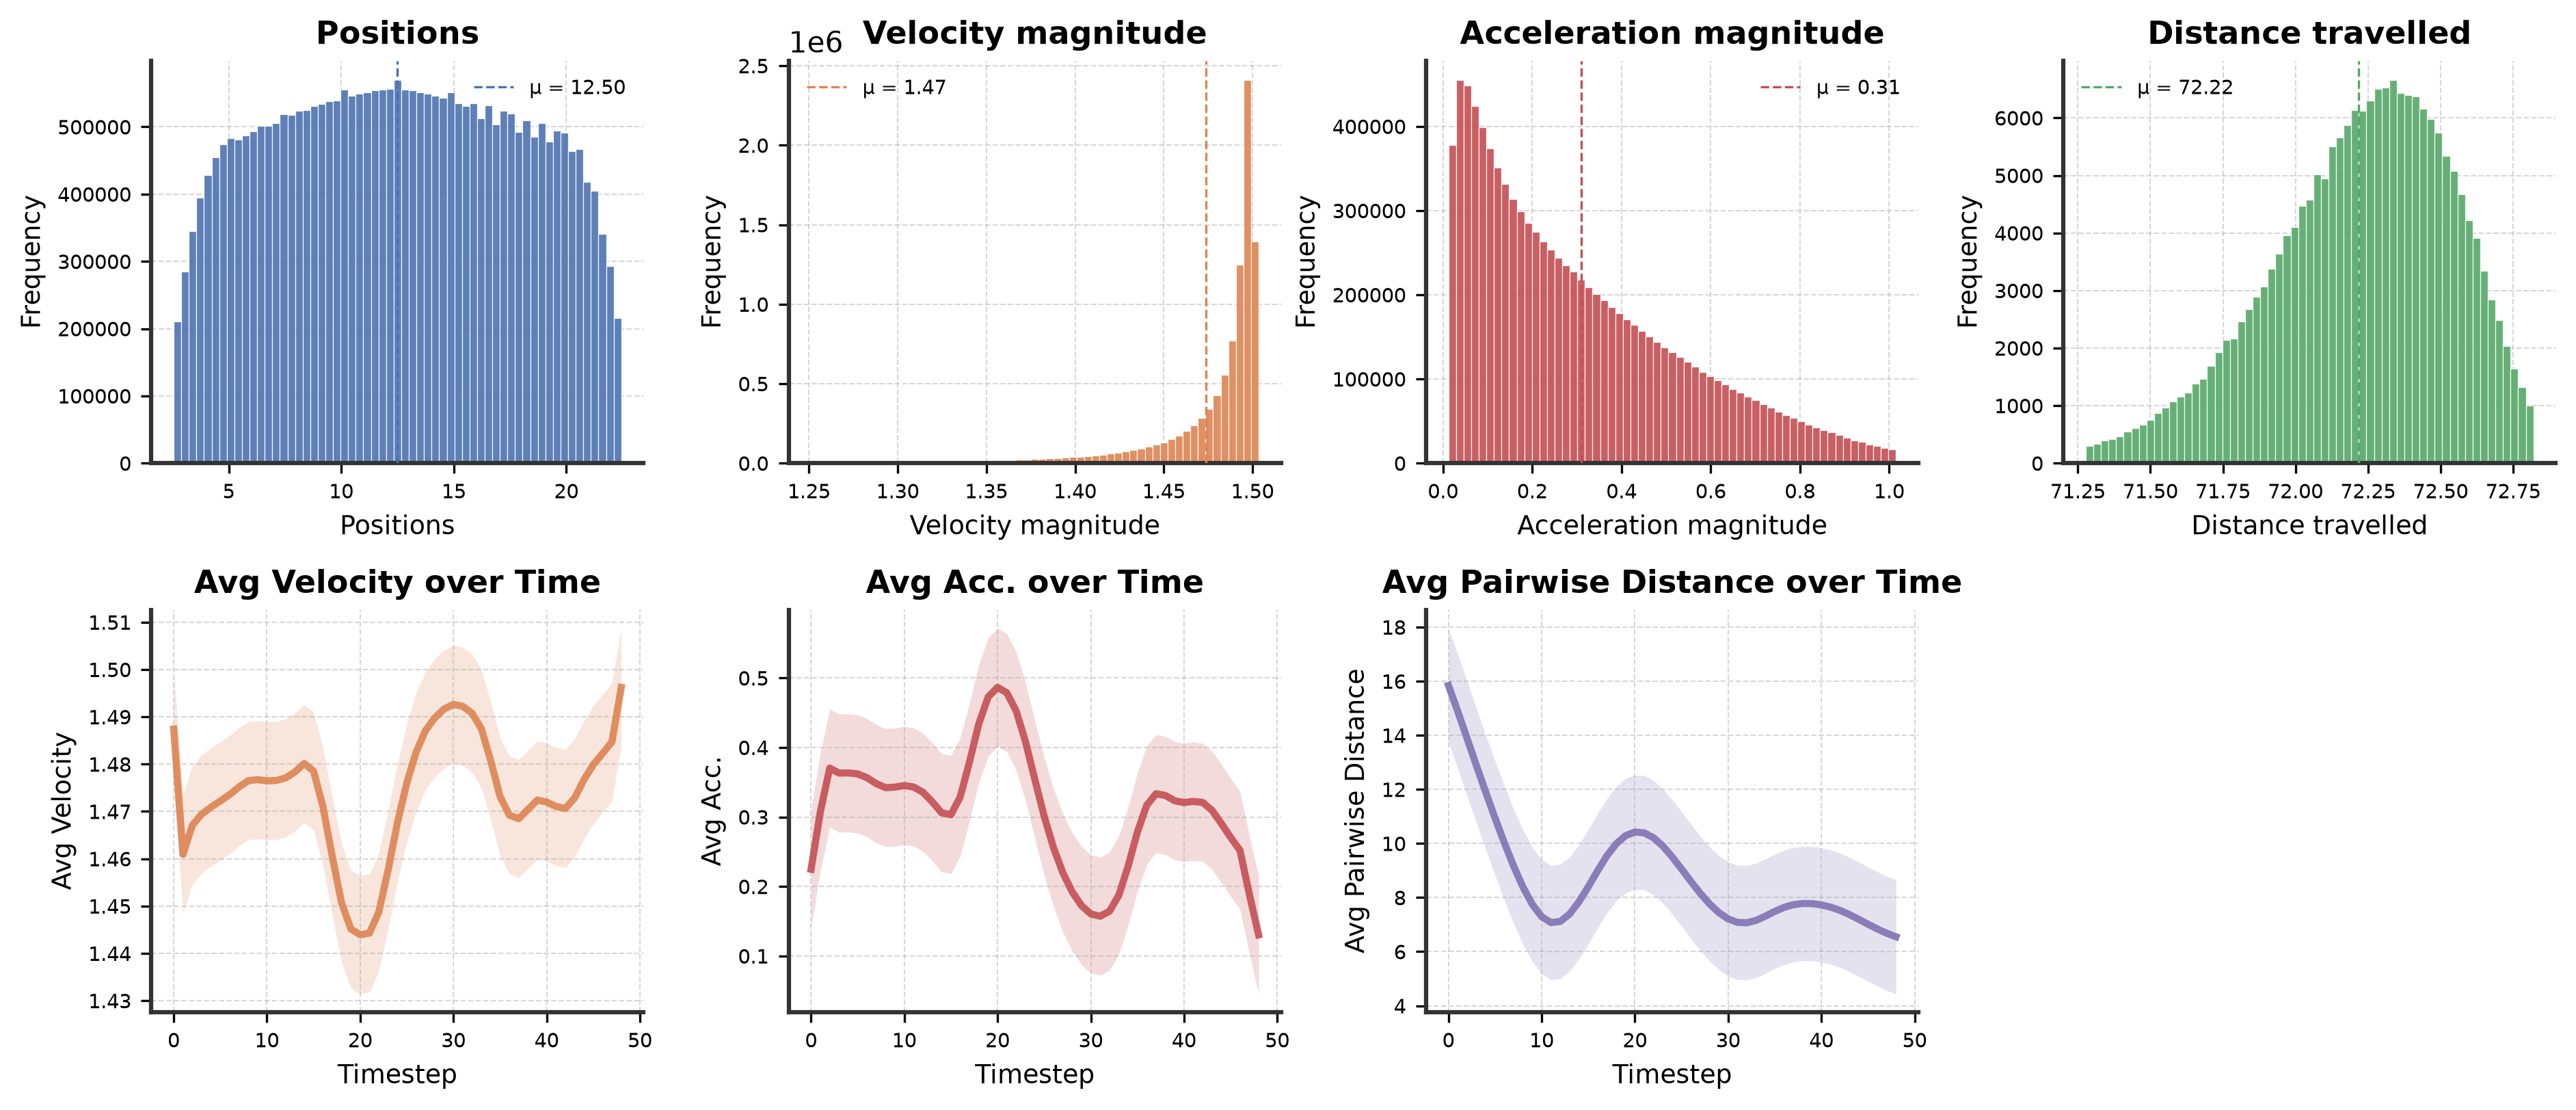

In [110]:
# Perform the exploratory data analysis here

dt = 1  # Time step size

# Positions shape: (#simulations, #time_steps, #boids, 3)
positions = boids_dataset.nodes[:, :, :, :3].numpy()


def calculate_kinematics(positions, dt):
    velocities = np.gradient(positions, dt, axis=1)  # Velocities as differences in positions
    accelerations = np.gradient(velocities, dt, axis=1)  # Accelerations as differences in velocities
    vel_magnitudes = np.linalg.norm(velocities, axis=-1)  # Magnitudes of velocities
    acc_magnitudes = np.linalg.norm(accelerations, axis=-1)  # Magnitudes of accelerations
    arc_lengths = np.sum(vel_magnitudes, axis=1)  # Distance travelled by every boid
    mean_vel_over_time = np.mean(vel_magnitudes, axis=(0, 2))
    mean_acc_over_time = np.mean(acc_magnitudes, axis=(0, 2))

    # Avg distance between boids over time
    # For each timestep, take the position of the boid, calculate pairwise distances, then get the average
    n_simulations = positions.shape[0]
    n_timesteps = positions.shape[1]
    batch_size = 50 # We must keep this at a number that 2000 is divisible by (so all batches are same size)

    mean_dist_over_time = np.zeros(n_timesteps)

    for t in range(n_timesteps):
        distances_t = []

        for start in range(0, n_simulations, batch_size):
            pos_batch = positions[start:start + batch_size, t]

            relative_positions = (
                pos_batch[:, :, None] - pos_batch[:, None, :]
            )

            distances = np.linalg.norm(relative_positions, axis=-1)

            n_boids = distances.shape[1]
            mask = ~np.eye(n_boids, dtype=bool)

            distances_t.append(np.mean(distances[:, mask]))

        mean_dist_over_time[t] = np.mean(distances_t)

    return {
        "velocities": velocities,
        "accelerations": accelerations,
        "vel_magnitudes": vel_magnitudes,
        "acc_magnitudes": acc_magnitudes,
        "arc_lengths": arc_lengths,
        "mean_vel_over_time": mean_vel_over_time,
        "mean_acc_over_time": mean_acc_over_time,
        "mean_dist_over_time": mean_dist_over_time
    }

def plot_kinematics_summary(hist_quantities, hist_names, hist_colors,
                            line_quantities, line_names, line_colors, displ_error_labels= None, model_labels=None):
    """2x4 grid: row 0 = histograms, row 1 = temporal mean +/- std."""
    fig, axs = plt.subplots(2, 4, figsize=(12.5, 5.5), dpi=300)

    def _as_tuple(x):
        return x if isinstance(x, tuple) else (x,)

    def _apply_ax_styles(ax):
        """Applies axis frame and tick styling locally."""
        ax.tick_params(axis='both', labelsize=7)
        for spine in ax.spines.values():
            spine.set_color('#333333')
            spine.set_linewidth(1.5)

    # --- Row 0: Histograms ---
    for ax, vals, name, color in zip(axs[0], hist_quantities, hist_names, hist_colors):
        _apply_ax_styles(ax)
        vals_t, color_t = _as_tuple(vals), _as_tuple(color)
        labels_t = model_labels if (model_labels and len(vals_t) > 1) else [None] * len(vals_t)

        flat = [v.flatten() for v in vals_t]
        lo = min(np.quantile(v, 0.01) for v in flat)
        hi = max(np.quantile(v, 0.99) for v in flat)
        bins = np.linspace(lo, hi, 60)

        for v, c, lbl in zip(flat, color_t, labels_t):
            alpha = 0.4 if len(vals_t) > 1 else 0.9
            ax.hist(v, bins=bins, color=c, alpha=alpha, edgecolor='white',
                    linewidth=0.3, zorder=2)
            label = f'μ = {np.mean(v):.2f}' if lbl is None else f'{lbl} μ = {np.mean(v):.2f}'
            ax.axvline(np.mean(v), color=c, linestyle='--', linewidth=0.8,
                       zorder=3, label=label)

        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel(name, fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(loc='best', fontsize=7, frameon=False)
        ax.grid(alpha=0.5, linestyle='--', linewidth=0.5, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)

    # --- Row 1: Temporal statistics ---
    for ax, vals, name, color in zip(axs[1], line_quantities, line_names, line_colors):
        _apply_ax_styles(ax)
        vals_t, color_t = _as_tuple(vals), _as_tuple(color)
        labels_t = model_labels if (model_labels and len(vals_t) > 1) else [None] * len(vals_t)
        if displ_error_labels is not None and name == 'Displ. Error':
            labels_t = displ_error_labels

        for v, c, lbl in zip(vals_t, color_t, labels_t):
            t = np.arange(len(v))
            std = np.std(v)
            ax.plot(t, v, color=c, linewidth=2.5, zorder=2, label=lbl, alpha=0.9)
            ax.fill_between(t, v - std, v + std, color=c, alpha=0.2, linewidth=0)

        ax.set_title(f'{name} over Time', fontsize=11, fontweight='bold')
        ax.set_xlabel('Timestep', fontsize=9)
        ax.set_ylabel(name, fontsize=9)
        if any(labels_t):
            ax.legend(loc='best', fontsize=7, frameon=False)
        ax.grid(alpha=0.5, linestyle='--', linewidth=0.5, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide unused axes if fewer than 4 plots are given
    for ax in axs[1][len(line_quantities):]:
        ax.axis('off')
    for ax in axs[0][len(hist_quantities):]:
        ax.axis('off')

    fig.tight_layout(pad=0.5, h_pad=1.0)
    return fig, axs

properties = calculate_kinematics(positions, dt)

hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [positions, properties['vel_magnitudes'], properties['acc_magnitudes'], properties['arc_lengths']]
hist_colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

line_names = ['Avg Velocity', 'Avg Acc.', 'Avg Pairwise Distance']
line_values = [properties['mean_vel_over_time'], properties['mean_acc_over_time'], properties['mean_dist_over_time']]
line_colors = ['#DD8452', '#C44E52', '#8172B2']

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors,
                                    line_values, line_names, line_colors)
plt.show()

In [111]:
class EGNNLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, C=1.0):
        super().__init__()

        self.C = C

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1 + edge_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        self.velocity_mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1, bias=False),
        )

        T.nn.init.xavier_uniform_(self.coord_mlp[-1].weight, gain=0.001)

        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, node_dim),
        )

    def forward(self, h, x, v_init, edge_index, edge_attr):
        src, dst = edge_index

        rel = x[src] - x[dst]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)

        m = self.edge_mlp(T.cat([h[src], h[dst], dist2, edge_attr], dim=-1))

        # Added so the update scale doesnt grow just because there are more boids
        degree = h.new_zeros(h.shape[0], 1)
        degree.index_add_(0, dst, h.new_ones(dst.shape[0], 1))
        degree = degree.clamp(min=1)

        agg = h.new_zeros(h.shape[0], m.shape[-1])
        agg.index_add_(0, dst, m)
        agg = agg / degree

        h_new = self.node_mlp(T.cat([h, agg], dim=-1))

        velocity_scale = T.sigmoid(self.velocity_mlp(h)) # Restrict the scale to 0 < velocity < 1

        dv = (x[src] - x[dst]) * T.tanh(self.coord_mlp(m)) # tanh to prevent exploding rollout
        interaction = v_init.new_zeros(v_init.shape)
        interaction.index_add_(0, dst, dv)
        interaction = interaction / degree

        v_new = velocity_scale * v_init + self.C * interaction
        x_new = x + v_new

        return h_new, x_new, v_new

class EGNN(nn.Module):

    def __init__(self):
        super().__init__()
        hidden_dim = 32
        self.node_in = nn.Linear(1, hidden_dim)

        self.layers = nn.ModuleList([
            EGNNLayer(node_dim=hidden_dim, edge_dim=1, hidden_dim=hidden_dim)
            for _ in range(2)
        ])

    def forward(self, x, edge_index, edge_attr):

        positions = x[..., :3]
        velocities = x[..., 3:6]
        h = x[..., 6:]

        h = self.node_in(h)

        for layer in self.layers:
            h, positions, velocities = layer(h, positions, velocities, edge_index, edge_attr)

        return velocities

In [112]:
class BoidsModel(L.LightningModule):
    def __init__(self, model, learning_rate=5e-4):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x, edge_index, edge_attr):
        return self.model(x, edge_index, edge_attr)

    def _step(self, batch):
        inputs = batch.x
        targets = batch.y[..., 3:6]
        outputs = self(inputs, batch.edge_index, batch.edge_attr)
        loss = F.mse_loss(outputs, targets)
        return loss

    def training_step(self, batch):
        loss = self._step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        loss = self._step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch):

        rollout = T.zeros_like(batch.x)
        rollout[:, 0] = batch.x[:, 0]

        for t in range(0, rollout.shape[1] - 1):
            old_positions = rollout[:, t, :3]
            model_input = rollout[:, t]

            edge_attr = edge_features_egnn(model_input[:, 3:6], batch.edge_index)

            new_velocities = self(model_input, batch.edge_index, edge_attr)
            new_positions = old_positions + new_velocities

            rollout[:, t + 1, :6] = T.cat([new_positions, new_velocities], dim=-1)
            rollout[:, t + 1, 6] = T.norm(new_velocities, dim=-1)

        rollout, _ = to_dense_batch(rollout, batch.batch)
        return rollout

    def configure_optimizers(self):
        return T.optim.Adam(self.parameters(), lr=self.learning_rate)

class LossHistory(L.Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get("train_loss").item())
    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get("val_loss").item())

In [113]:
# Initialize dataset
dataset = BoidsStepDataset(path)

# Initialize datamodule
datamodule = DataModule(dataset)

# Initialize model
egnn = EGNN()
model = BoidsModel(egnn)

# Initialize trainer
loss_history = LossHistory()
trainer = L.Trainer(max_epochs=40, callbacks=[loss_history], enable_progress_bar=True) # Added max epochs

# Fit the model to the dataset
trainer.fit(model, datamodule=datamodule)

# Load the inference dataset 
traj_dataset = BoidsTrajectoryDataset(path)
datamodule = DataModule(traj_dataset)

# Perform inference
rollouts = trainer.predict(model, datamodule=datamodule)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type | Params | Mode  | FLOPs
-----------------------------------------------
0 | model | EGNN | 17.1 K | train | 0    
-----------------------------------------------
17.1 K    Trainable params
0         Non-trainable params
17.1 K    Total params
0.068     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode
0         Total Flops



Loaded data from /Users/filipprokes/Documents/GitHub/ml4sci-2026/assignments/../data/boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)

Epoch 39: 100%|██████████| 2100/2100 [03:14<00:00, 10.79it/s, v_num=7, val_loss=0.0308, train_loss=0.0309]

`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 39: 100%|██████████| 2100/2100 [03:14<00:00, 10.79it/s, v_num=7, val_loss=0.0308, train_loss=0.0309]

Loaded data from /Users/filipprokes/Documents/GitHub/ml4sci-2026/assignments/../data/boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)

Predicting DataLoader 0: 100%|██████████| 13/13 [00:12<00:00,  1.05it/s]


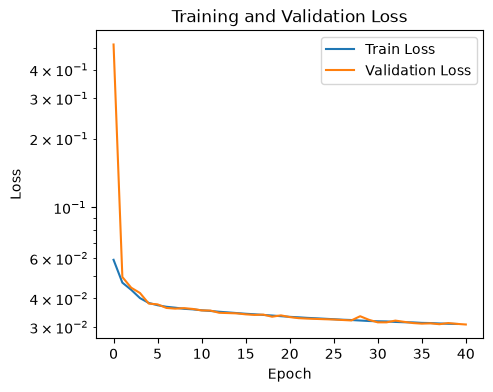

In [114]:
# Evaluate the model and make plots here

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

ax.plot(loss_history.train_loss, label='Train Loss', color='tab:blue')
ax.plot(loss_history.val_loss, label='Validation Loss', color='tab:orange')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.title('Training and Validation Loss')
plt.show()

/var/folders/92/s31_r8x970zbgrgsk27rmq980000gn/T/ipykernel_58622/1133274814.py:130: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  return GraphDataLoader(self.test_set, batch_size=self.batch_size)


Average Displacement Error (ADE): 22.7862
Final Displacement Error (FDE): 35.7486


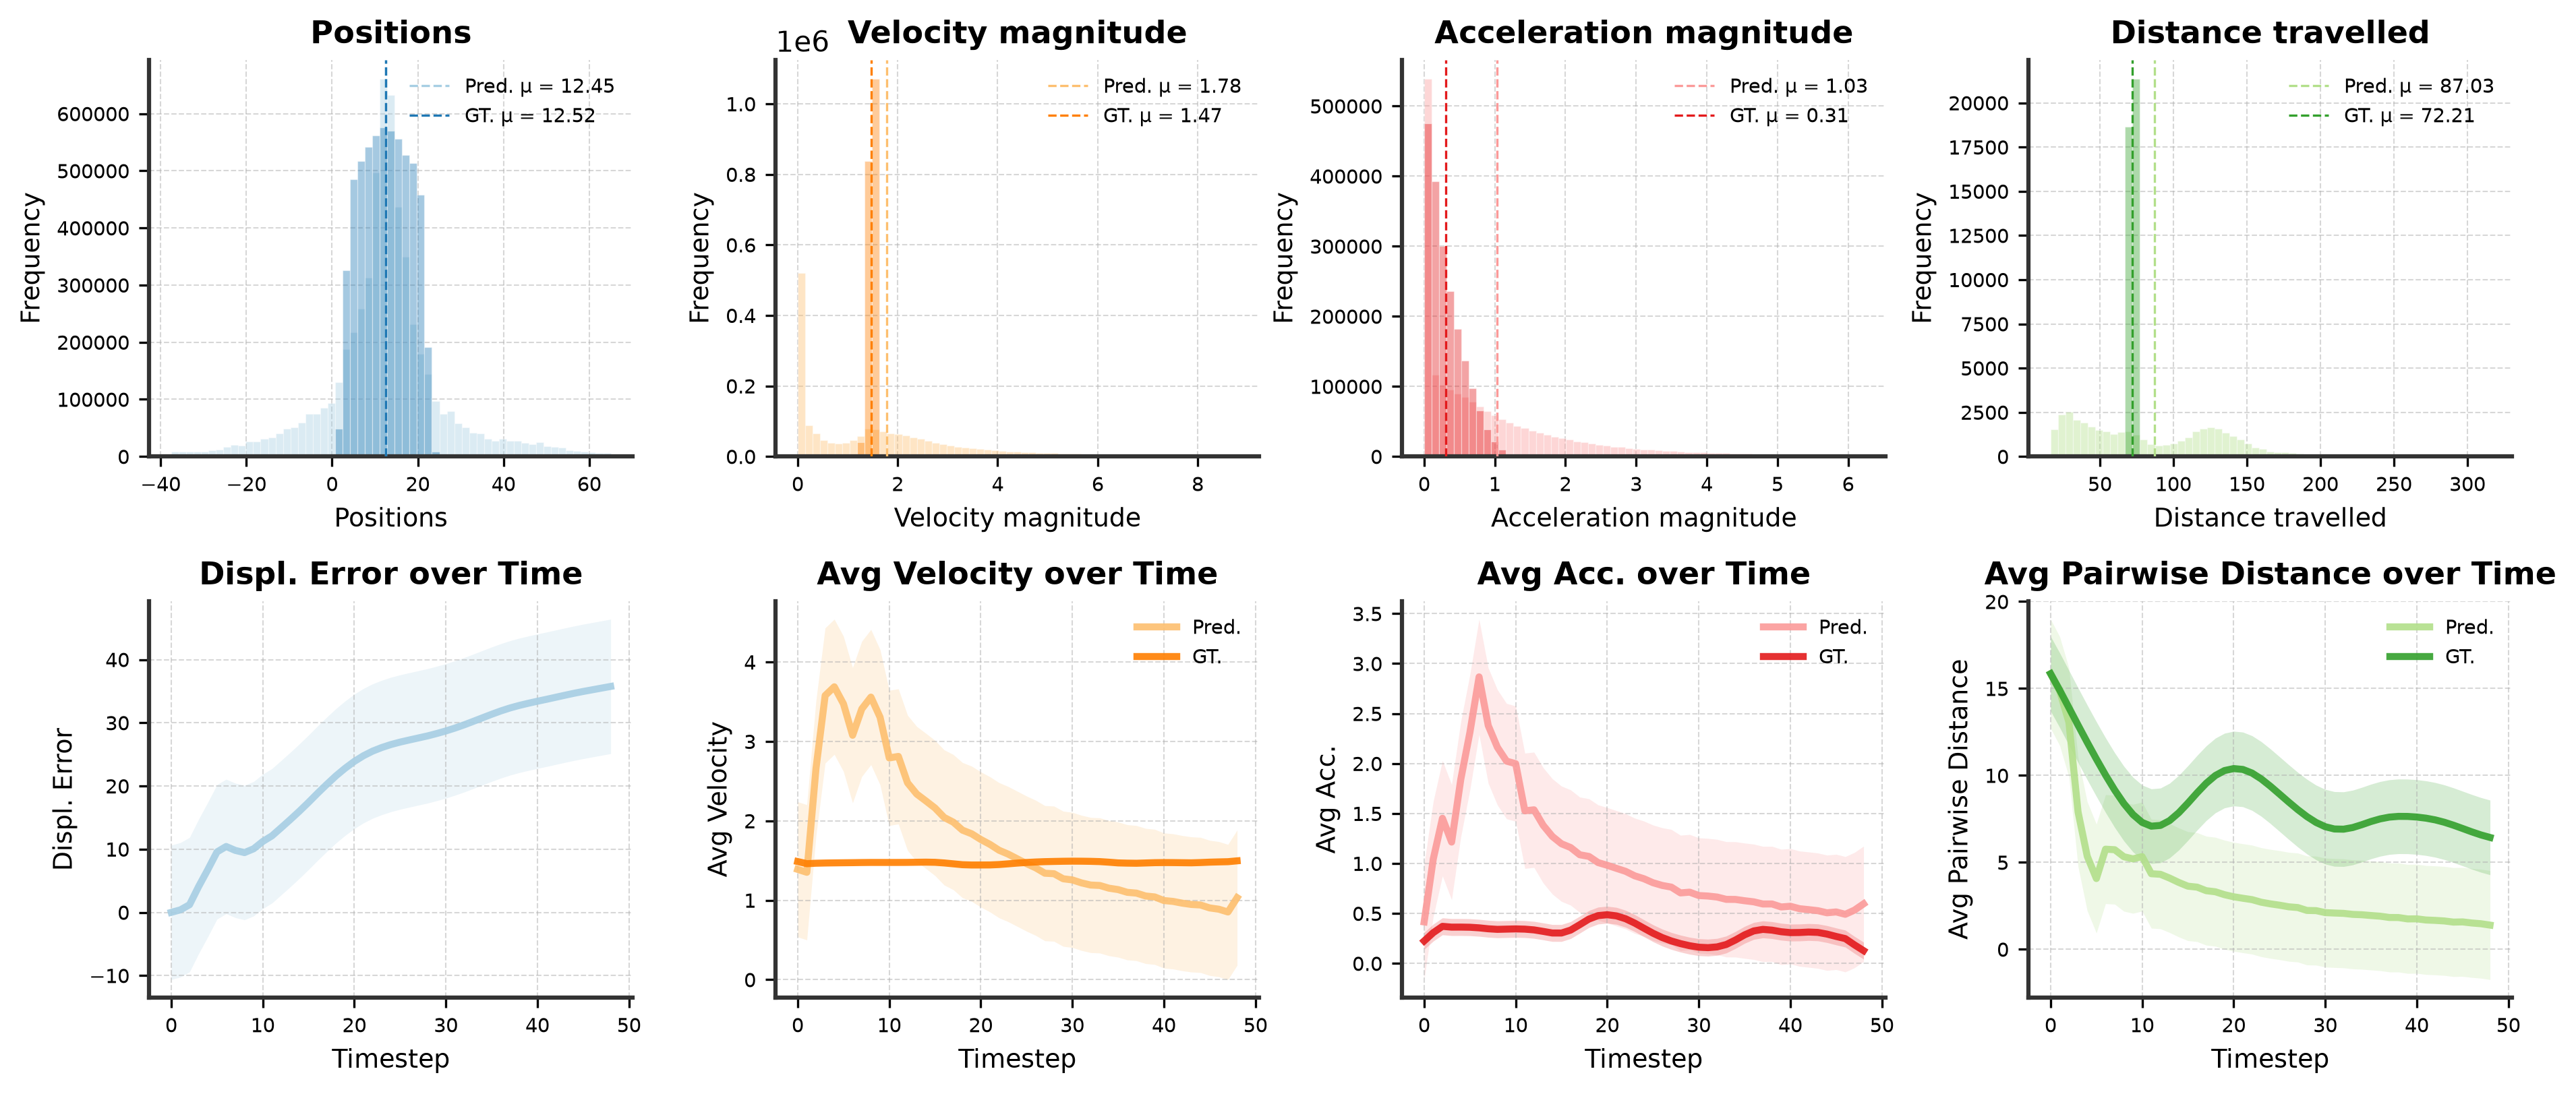

In [116]:
predicted = T.cat(rollouts, dim=0).transpose(1, 2).cpu().numpy()
ground_truths = [to_dense_batch(data.x, data.batch)[0] for data in datamodule.predict_dataloader()]
ground_truth = T.cat(ground_truths, dim=0).transpose(1, 2).cpu().numpy() # I added the cpu for assuring it runs as intended on my Mac device

predicted_positions = predicted[..., :3]
ground_truth_positions = ground_truth[..., :3]

pred = calculate_kinematics(predicted_positions, dt)
gt = calculate_kinematics(ground_truth_positions, dt)

displacement_errors = np.linalg.norm(predicted_positions - ground_truth_positions, axis=-1)
ADE = np.mean(displacement_errors)
FDE = np.mean(displacement_errors[:, -1])
DE_over_time = np.mean(displacement_errors, axis=(0, 2))

print(f"Average Displacement Error (ADE): {ADE:.4f}")
print(f"Final Displacement Error (FDE): {FDE:.4f}")

hist_names = ['Positions', 'Velocity magnitude', 'Acceleration magnitude', 'Distance travelled']
hist_values = [(predicted_positions, ground_truth_positions),
               (pred['vel_magnitudes'], gt['vel_magnitudes']),
               (pred['acc_magnitudes'], gt['acc_magnitudes']),
               (pred['arc_lengths'], gt['arc_lengths'])]

cmap = plt.get_cmap('Paired')

hist_colors_compare = [(cmap(0), cmap(1)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]
line_colors_compare = [(cmap(0), cmap(1)), (cmap(6), cmap(7)), (cmap(4), cmap(5)), (cmap(2), cmap(3))]

line_names = ['Displ. Error', 'Avg Velocity', 'Avg Acc.', 'Avg Pairwise Distance']
line_values = [DE_over_time,
               (pred['mean_vel_over_time'], gt['mean_vel_over_time']),
               (pred['mean_acc_over_time'], gt['mean_acc_over_time']),
               (pred['mean_dist_over_time'], gt['mean_dist_over_time'])]

%matplotlib inline
fig, axs = plot_kinematics_summary(hist_values, hist_names, hist_colors_compare,
                                   line_values, line_names, line_colors_compare,
                                   model_labels=['Pred.', 'GT.'])
plt.show()